In [5]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.4 MB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 233 kB 113.4 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys; print(sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
%matplotlib inline

df = pd.read_csv("week-5-country-life-satisfaction.csv", index_col=0)
df.head()

3.9.25 (main, Dec 19 2025, 15:38:47) 
[GCC 8.5.0 20210514 (Red Hat 8.5.0-28.0.1)]


,Name,LifeSat,CountryCode,Region,HDI,LE,EYS,MYS,GNI
1,Afghanistan,3.794,AFG,South Asia,0.495960,64.486,10.138920,3.930000,1745.665705
2,Albania,4.644,ALB,Europe & Central Asia,0.791406,78.458,15.230000,10.054618,12299.799340
3,Algeria,5.872,DZA,Middle East & North Africa,0.758978,76.693,14.719379,7.986548,13639.434910
4,Angola,3.795,AGO,Sub-Saharan Africa,0.574488,60.782,11.777202,5.125460,5554.697384
5,Argentina,6.599,ARG,Latin America & Caribbean,0.830096,76.520,17.638360,10.564965,17611.218130


1. Exploring the data (2 mark)
(a). Load the CSV into a DataFrame. Print its shape, the column data types, and the number of
missing values per column


In [8]:
print(df.shape)

(134, 9)


In [9]:
df.dtypes

Name            object
LifeSat        float64
CountryCode     object
Region          object
HDI            float64
LE             float64
EYS            float64
MYS            float64
GNI            float64
dtype: object

(b). Create a new column logGNI = log(GNI) using np.log. Plot histograms of GNI and logGNI side
by side and state in one sentence why the log transform is preferred as an indicator.

In [10]:
df["logGNI"]=np.log(df.GNI)

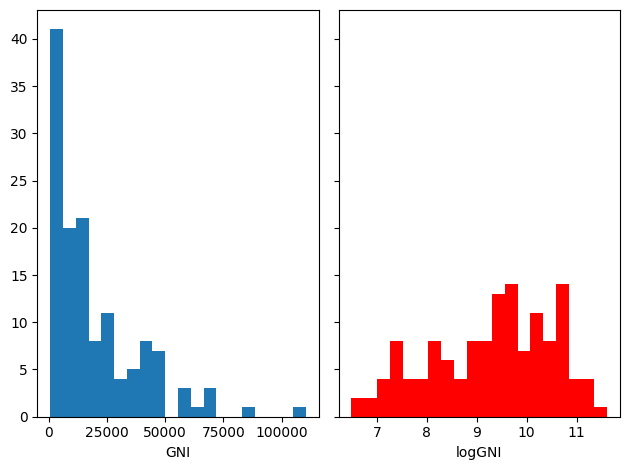

In [16]:
n_bins=20
fig,axs=plt.subplots(1,2,sharey=True,tight_layout=True)
axs[0].hist(df["GNI"],bins=n_bins)
axs[0].set_xlabel("GNI")
axs[1].hist(df["logGNI"],bins=n_bins,color = "red")
axs[1].set_xlabel("logGNI")
plt.show()

Log transform is preferred since we are working with data which is related y exponentional equation the log transform turns the exponential to a linear data which is much simpler to work with.

(c). Produce a pairwise plot (e.g. seaborn.pairplot) of LifeSat, LE, EYS, MYS and logGNI, and
print the correlation matrix of these five variables (rounded to 2 decimals).


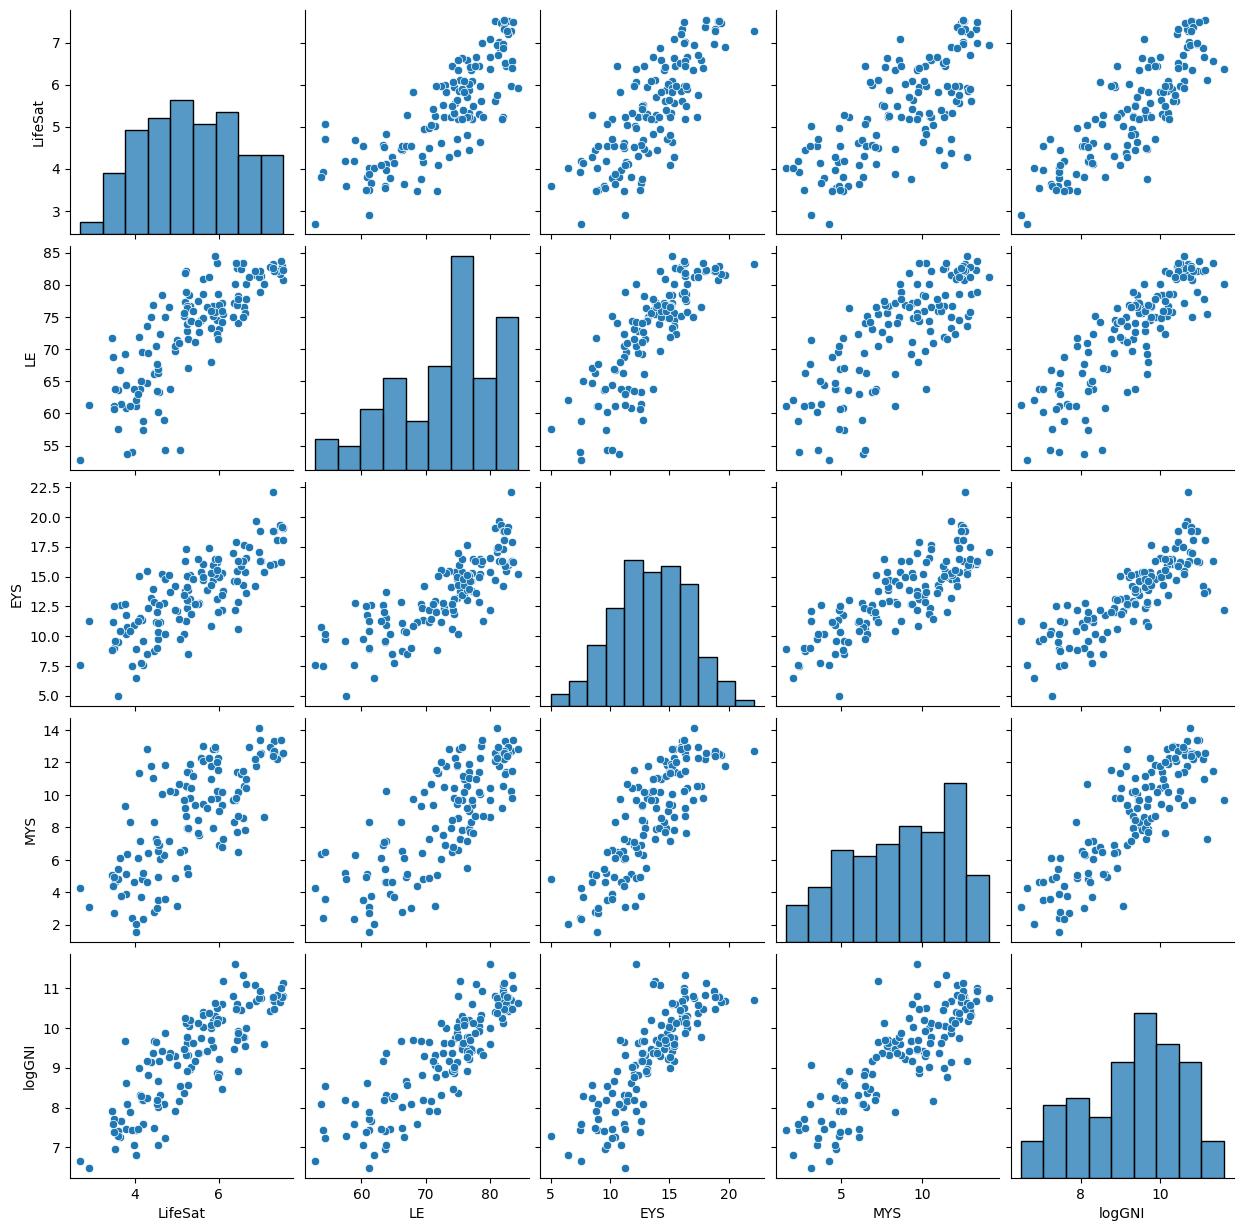

In [24]:
sns.pairplot(df[['LifeSat','LE','EYS','MYS','logGNI']])

In [25]:
df[["LifeSat","LE","EYS","MYS","logGNI"]].corr().round(2)

,LifeSat,LE,EYS,MYS,logGNI
LifeSat,1.00,0.81,0.77,0.72,0.84
LE,0.81,1.00,0.81,0.78,0.86
EYS,0.77,0.81,1.00,0.82,0.83
MYS,0.72,0.78,0.82,1.00,0.84
logGNI,0.84,0.86,0.83,0.84,1.00


d). Which indicator is most strongly correlated with LifeSat? Which pair of indicators is most
strongly correlated with each other?

ans: The indicator with most correlation to LifeSat other than itself is logGNI. the pair of indicators with most correlation are (LE,logGNI) with correlaton 0.86.

2. Fitting the model
(a)Fit a linear regression predicting LifeSat from LE, EYS, MYS and logGNI. Print the full summary
(coefficients, standard errors, p-values, R2 and adjusted R2).

In [31]:
X=df[['LE','EYS','MYS','logGNI']]
Y=df['LifeSat']
model = smf.ols("Y~X",data=df)
result=model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     91.77
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.07e-37
Time:                        15:00:50   Log-Likelihood:                -120.17
No. Observations:                 134   AIC:                             250.3
Df Residuals:                     129   BIC:                             264.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.9442      0.668     -4.405      0.000      -4.267      -1.622
X[0]           0.0415      0.014      3.020      0.003       0.014       0.069
X[1]           0.0654      0.034      1.906      0.059      -0.002       0.133
X[2]          -0.0290      0.033     -0.876      0.383      -0.094       0.036
X[3]           0.5017      0.102      4.937      0.000       0.301       0.703
==============================================================================
Omnibus:                        1.990   Durbin-Watson:                   2.131
Prob(Omnibus):                  0.370   Jarque-Bera (JB):                1.565
Skew:                          -0.080   Prob(JB):                        0.457
Kurtosis:                       2.496   Cond. No.                         970.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(b). Write down the fitted regression equation with the estimated coefficients.
ans: Since this is a linear regression model the equation will be linear with predictors as X
      equation: LifeSat(outcome) = 0.0415(LE) + 0.0654(EYS) - 0.0290(MYS) + 0.5017(logGNI) -2.9442

(c). Which indicators most strongly predict life satisfaction? Which ones are not statistically sig-
nificant
ans: logGNI is a strong predictor. EYS,MYS are not statistically significant due to higher p value than t.
    

(d). One coefficient has a sign that makes little substantive sense. Identify it and explain in 2–3
sentences how this can happen even though that indicator was positively correlated with LifeSat
in Q1.
Ans: The Mean years of Schooling is having a negative coefficient. This makes sense since people will not be happy with a life with higher years of schooling as school life has many restrictions on what a person can or cannot do. Since people in schooling are expected to follow life in such a way that benefits the institution they are affiliated with.The positive correlation can just be a coincidence as since higher education can lead to better employment due to skill hence having a better job is related to higher education and better job is directly linked to better LifeSat as we can see that logGNI's coefficient is high.

3. Comparing with an existing index (2 marks)
(a). EYS and MYS are strongly correlated and largely measure the same concept. Drop the one whose
coefficient made less substantive sense in Q2, refit the regression . Call this reduced model
model2; use it for Questions 3 and 4.

In [32]:
X2=df[['LE','EYS','logGNI']]
Y2=df['LifeSat']
model2 = .fit()
result2.summary()smf.ols("Y2~X2",data=df)
result2=model2.fit()
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     Y2   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     122.3
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           1.10e-37
Time:                        15:25:11   Log-Likelihood:                -120.56
No. Observations:                 134   AIC:                             249.1
Df Residuals:                     130   BIC:                             260.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6394      0.570     -4.630      0.000      -3.767      -1.512
X2[0]          0.0405      0.014      2.961      0.004       0.013       0.068
X2[1]          0.0545      0.032      1.706      0.090      -0.009       0.118
X2[2]          0.4653      0.093      5.022      0.000       0.282       0.649
==============================================================================
Omnibus:                        1.487   Durbin-Watson:                   2.147
Prob(Omnibus):                  0.476   Jarque-Bera (JB):                1.339
Skew:                          -0.103   Prob(JB):                        0.512
Kurtosis:                       2.556   Cond. No.                         821.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(b). The dataset contains HDI, which is built from these same indicators using a fixed formula. Com-
pute the correlation between the fitted values of model2 and HDI.

In [37]:
fitted_values=result2.fittedvalues
hdi=df["HDI"]
LifeSat=df["LifeSat"]
print("Fitted_values vs HDI :")
print(hdi.corr(fitted_values))

Fitted_values vs HDI :
0.9890412322483967
LifeSat vs HDI :
0.8428343075288518


(c). Compute the correlation between LifeSat and HDI.

In [38]:
print("LifeSat vs HDI :")
print(hdi.corr(LifeSat))

LifeSat vs HDI :
0.8428343075288518


(d). Draw two scatter plots (fitted values vs. HDI; LifeSat vs. HDI)

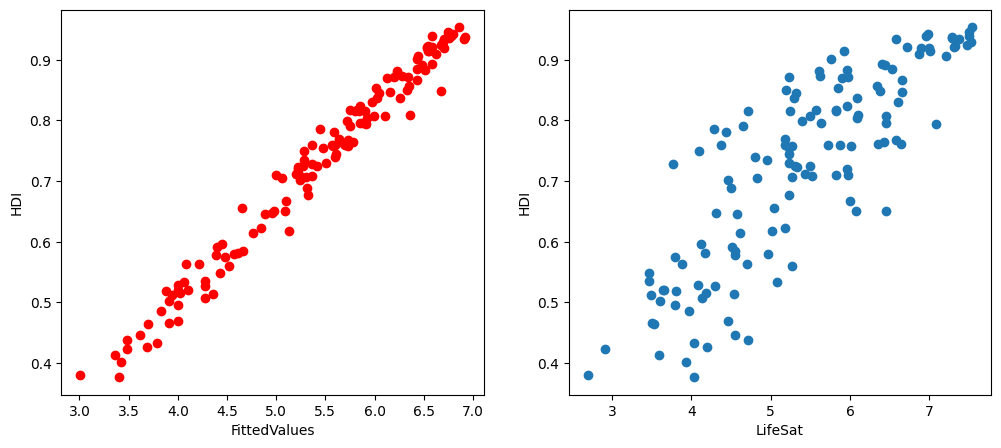

In [45]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].scatter(fitted_values,hdi,c="red")
ax[0].set_ylabel("HDI")
ax[0].set_xlabel("FittedValues")
ax[1].scatter(LifeSat,hdi)
ax[1].set_ylabel("HDI")
ax[1].set_xlabel("LifeSat")
plt.show()

4. Looking at the residuals
(a). Compute the residuals of model2 and identify the country with the largest positive residual
and the one with the largest negative residual.

In [47]:
Min=np.argmin(result2.resid)
Max=np.argmax(result2.resid)
print(f"Country with largest positive residual :{df.iloc[Max].Name}")
print(f"Country with largest negative residual :{df.iloc[Min].Name}")

Country with largest positive residual :Guatemala
Country with largest negative residual :Botswana


(b). Print a table comparing these two countries on LifeSat, HDI, LE, EYS, MYS, GNI and Region

In [67]:
table=pd.DataFrame()
table=pd.concat((df.iloc[Max][["Name","LifeSat","HDI","LE","EYS","MYS","GNI"]],df.iloc[Min][["Name","LifeSat","HDI","LE","EYS","MYS","GNI"]]),axis=1)
table

,48,18
Name,Guatemala,Botswana
LifeSat,6.454,3.766
HDI,0.651035,0.727787
LE,74.063,69.275
EYS,10.62148,12.697235
MYS,6.467886,9.33
GNI,7377.915813,15951.3304


(c). Plot residuals against fitted values. Does the spread of the residuals look roughly constant?

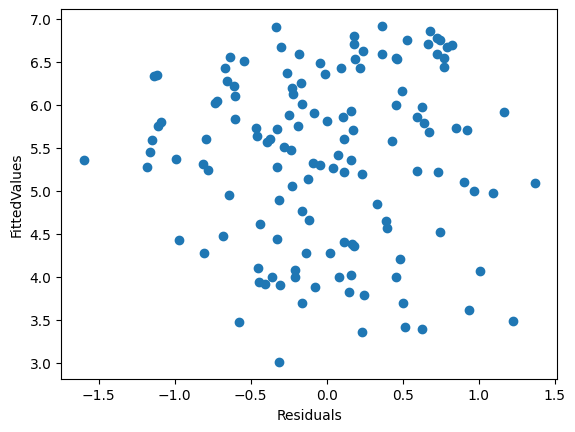

In [65]:
plt.scatter(result2.resid,fitted_values)
plt.xlabel("Residuals")
plt.ylabel("FittedValues")
plt.show()

Yes from left to right the spread is roughly constant.


5. Adding a categorical predictor (2 marks)
(a). Add Region to model2 as a set of dummy variables, using either pd.get dummies with
drop first=True or a formula with C(Region). Print the summary.

In [80]:
# print(model2)
# print(result2)
# pd.get_dummies(df,drop_first=True,columns=["Region"])
X2=df[['LE','EYS','logGNI']]
Y2=df['LifeSat']
model2 = smf.ols("Y2~X2+C(Region)",data=df)
result2=model2.fit()
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     Y2   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     49.89
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           4.84e-37
Time:                        16:24:56   Log-Likelihood:                -107.86
No. Observations:                 134   AIC:                             235.7
Df Residuals:                     124   BIC:                             264.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -2.5656      0.951     -2.697      0.008      -4.449      -0.682
C(Region)[T.Europe & Central Asia]         -0.1431      0.185     -0.772      0.442      -0.510       0.224
C(Region)[T.Latin America & Caribbean]      0.5983      0.211      2.832      0.005       0.180       1.016
C(Region)[T.Middle East & North Africa]    -0.1222      0.223     -0.548      0.585      -0.564       0.319
C(Region)[T.North America]                  0.6016      0.435      1.382      0.169      -0.260       1.463
C(Region)[T.South Asia]                    -0.0921      0.281     -0.328      0.743      -0.647       0.463
C(Region)[T.Sub-Saharan Africa]            -0.0101      0.247     -0.041      0.967      -0.499       0.479
X2[0]                                       0.0276      0.016      1.717      0.088      -0.004       0.059
X2[1]                                       0.0609      0.032      1.910      0.058      -0.002       0.124
X2[2]                                       0.5468      0.092      5.950      0.000       0.365       0.729
==============================================================================
Omnibus:                        0.339   Durbin-Watson:                   2.070
Prob(Omnibus):                  0.844   Jarque-Bera (JB):                0.502
Skew:                          -0.061   Prob(JB):                        0.778
Kurtosis:                       2.726   Cond. No.                     1.51e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

(b). State which region is the baseline category and explain what a region coefficient means, holding
the other indicators constant.
ans: (East asia & Pacific) are baseline since they are not present in the model summary.

c). Which regions report notably higher or lower life satisfaction than the baseline, and which of
these differences are statistically significant?
ans: Latin America & Carribbean has notably higher life satisfaction and Europe & Central Asia has
        less LifeSat this can be inferred from their coefficients.

Bonus (Optional) (+1 mark)
Split the data into a training set (80%) and a test set (20%) using train test split with a fixed
random state. Refit model2 on the training set, predict on the test set, and report the RMSE and
R2 on both.

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
X_train,X_test,Y_train,Y_test=train_test_split(X2,Y2,test_size=.2,random_state=42)
reg=LinearRegression().fit(X_train,Y_train)
Y_pred=reg.predict(X_test)
print(f"R2 Score: {reg.score(X_test,Y_test)}")#R^2
print(f"RMSE :{root_mean_squared_error(Y_test,Y_pred)}")

R2 Score: 0.6562806903830873
RMSE :0.6545235515071838
